# CIFAR-10 SNGP Embedding UMAP

Load saved SNGP embeddings and visualize train/test embeddings with a train-fit UMAP transform. This notebook does not load the model or run embedding extraction.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import umap
except ImportError as exc:
    raise ImportError("Install UMAP with `pip install umap-learn` before running this notebook.") from exc

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / "src").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

print("repo root:", REPO_ROOT)


/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: /w/20252/wjcai/uq/manygp


In [2]:
EMBEDDING_PATH = REPO_ROOT / "notebooks" / "gmm" / "sngp_embeddings_cifar10_sngp_epoch175_acc0.9323.npz"

if not EMBEDDING_PATH.exists():
    candidates = sorted((REPO_ROOT / "notebooks" / "gmm").glob("sngp_embeddings_*.npz"))
    if not candidates:
        raise FileNotFoundError("No sngp_embeddings_*.npz files found in notebooks/gmm. Run sngp_extract_embeddings.ipynb first.")
    EMBEDDING_PATH = candidates[-1]

data = np.load(EMBEDDING_PATH, allow_pickle=True)

train_embeddings = data["train_embeddings"]
train_labels = data["train_labels"]
test_embeddings = data["test_embeddings"]
test_labels = data["test_labels"]
classes = data["classes"] if "classes" in data else np.array([str(i) for i in range(10)])
checkpoint_id = str(data["checkpoint_id"]) if "checkpoint_id" in data else EMBEDDING_PATH.stem.removeprefix("sngp_embeddings_")

print("embedding file:", EMBEDDING_PATH)
print("checkpoint id:", checkpoint_id)
print("train embeddings:", train_embeddings.shape)
print("test embeddings:", test_embeddings.shape)
print("classes:", classes.tolist())

for optional_key in ("svhn_embeddings", "cifar100_test_embeddings"):
    if optional_key in data:
        print(optional_key + ":", data[optional_key].shape)


embedding file: /w/20252/wjcai/uq/manygp/notebooks/gmm/sngp_embeddings_cifar10_sngp_epoch175_acc0.9323.npz
checkpoint id: cifar10_sngp_epoch175_acc0.9323
train embeddings: (50000, 128)
test embeddings: (10000, 128)
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
svhn_embeddings: (26032, 128)
cifar100_test_embeddings: (10000, 128)


In [3]:
if "train_probs" in data:
    train_probs = data["train_probs"]
    train_preds = train_probs.argmax(axis=1)
    train_correct_mask = train_preds == train_labels
    train_accuracy = np.mean(train_correct_mask)
    train_entropy = -(np.clip(train_probs, 1e-12, 1.0) * np.log(np.clip(train_probs, 1e-12, 1.0))).sum(axis=1)
    print(f"train accuracy from saved probs: {train_accuracy * 100:.2f}%")
else:
    train_preds = None
    train_correct_mask = None
    train_entropy = None

if "test_probs" in data:
    test_probs = data["test_probs"]
    test_preds = test_probs.argmax(axis=1)
    test_correct_mask = test_preds == test_labels
    test_accuracy = np.mean(test_correct_mask)
    test_nll = -np.mean(np.log(np.clip(test_probs[np.arange(len(test_labels)), test_labels], 1e-12, 1.0)))
    test_entropy = -(np.clip(test_probs, 1e-12, 1.0) * np.log(np.clip(test_probs, 1e-12, 1.0))).sum(axis=1)
    print(f"test accuracy from saved probs: {test_accuracy * 100:.2f}%")
    print(f"test NLL from saved probs: {test_nll:.4f}")
else:
    test_preds = None
    test_correct_mask = None
    test_entropy = None

if "train_variances" in data:
    train_gp_variance = data["train_variances"].mean(axis=1)
    print(f"mean train GP variance: {train_gp_variance.mean():.4f}")
else:
    train_gp_variance = None

if "test_variances" in data:
    test_gp_variance = data["test_variances"].mean(axis=1)
    print(f"mean test GP variance: {test_gp_variance.mean():.4f}")
else:
    test_gp_variance = None


train accuracy from saved probs: 100.00%
test accuracy from saved probs: 93.18%
test NLL from saved probs: 0.3244
mean train GP variance: 0.8031
mean test GP variance: 0.7680


In [4]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

train_embedding_2d = umap_model.fit_transform(train_embeddings)
test_embedding_2d = umap_model.transform(test_embeddings)
print("train UMAP projection:", train_embedding_2d.shape)
print("test UMAP projection:", test_embedding_2d.shape)


/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


train UMAP projection: (50000, 2)
test UMAP projection: (10000, 2)


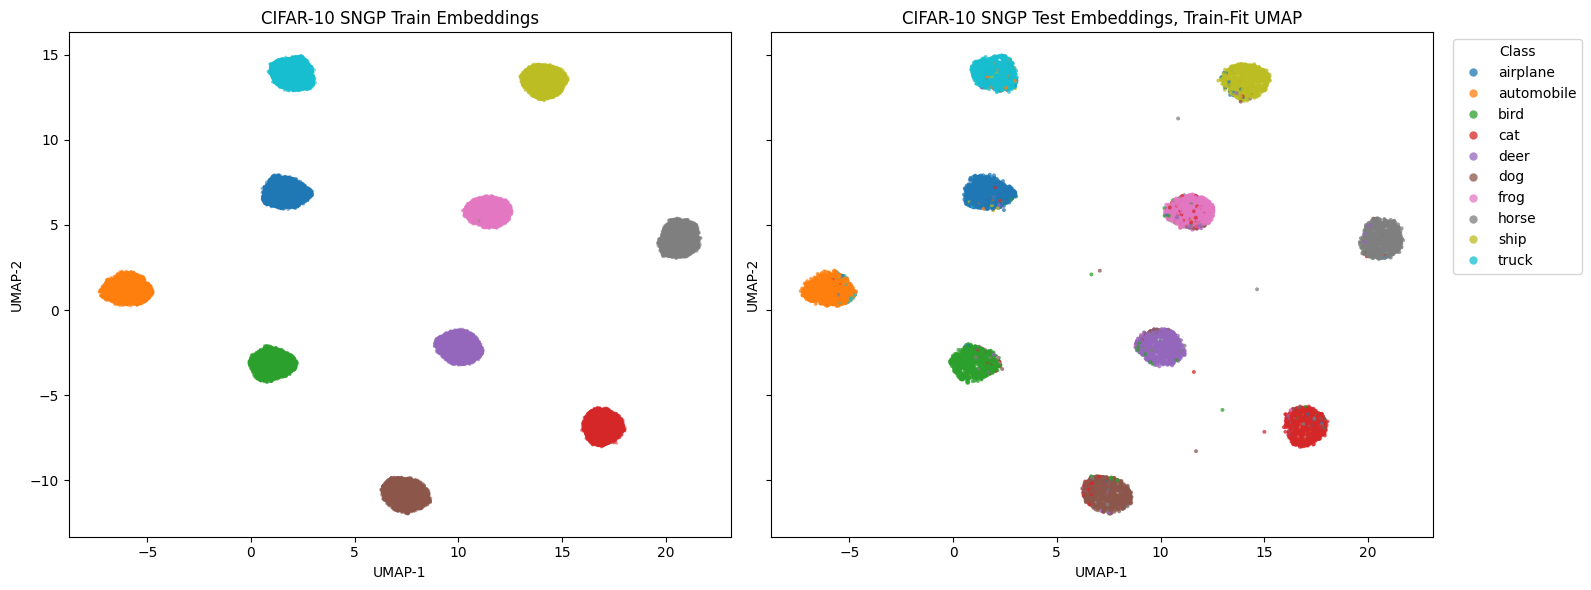

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

axes[0].scatter(
    train_embedding_2d[:, 0],
    train_embedding_2d[:, 1],
    c=train_labels,
    cmap="tab10",
    s=5,
    alpha=0.55,
    linewidths=0,
)
axes[0].set_title("CIFAR-10 SNGP Train Embeddings")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

test_scatter = axes[1].scatter(
    test_embedding_2d[:, 0],
    test_embedding_2d[:, 1],
    c=test_labels,
    cmap="tab10",
    s=8,
    alpha=0.75,
    linewidths=0,
)
axes[1].set_title("CIFAR-10 SNGP Test Embeddings, Train-Fit UMAP")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

handles, _ = test_scatter.legend_elements(num=len(classes))
axes[1].legend(handles, classes, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


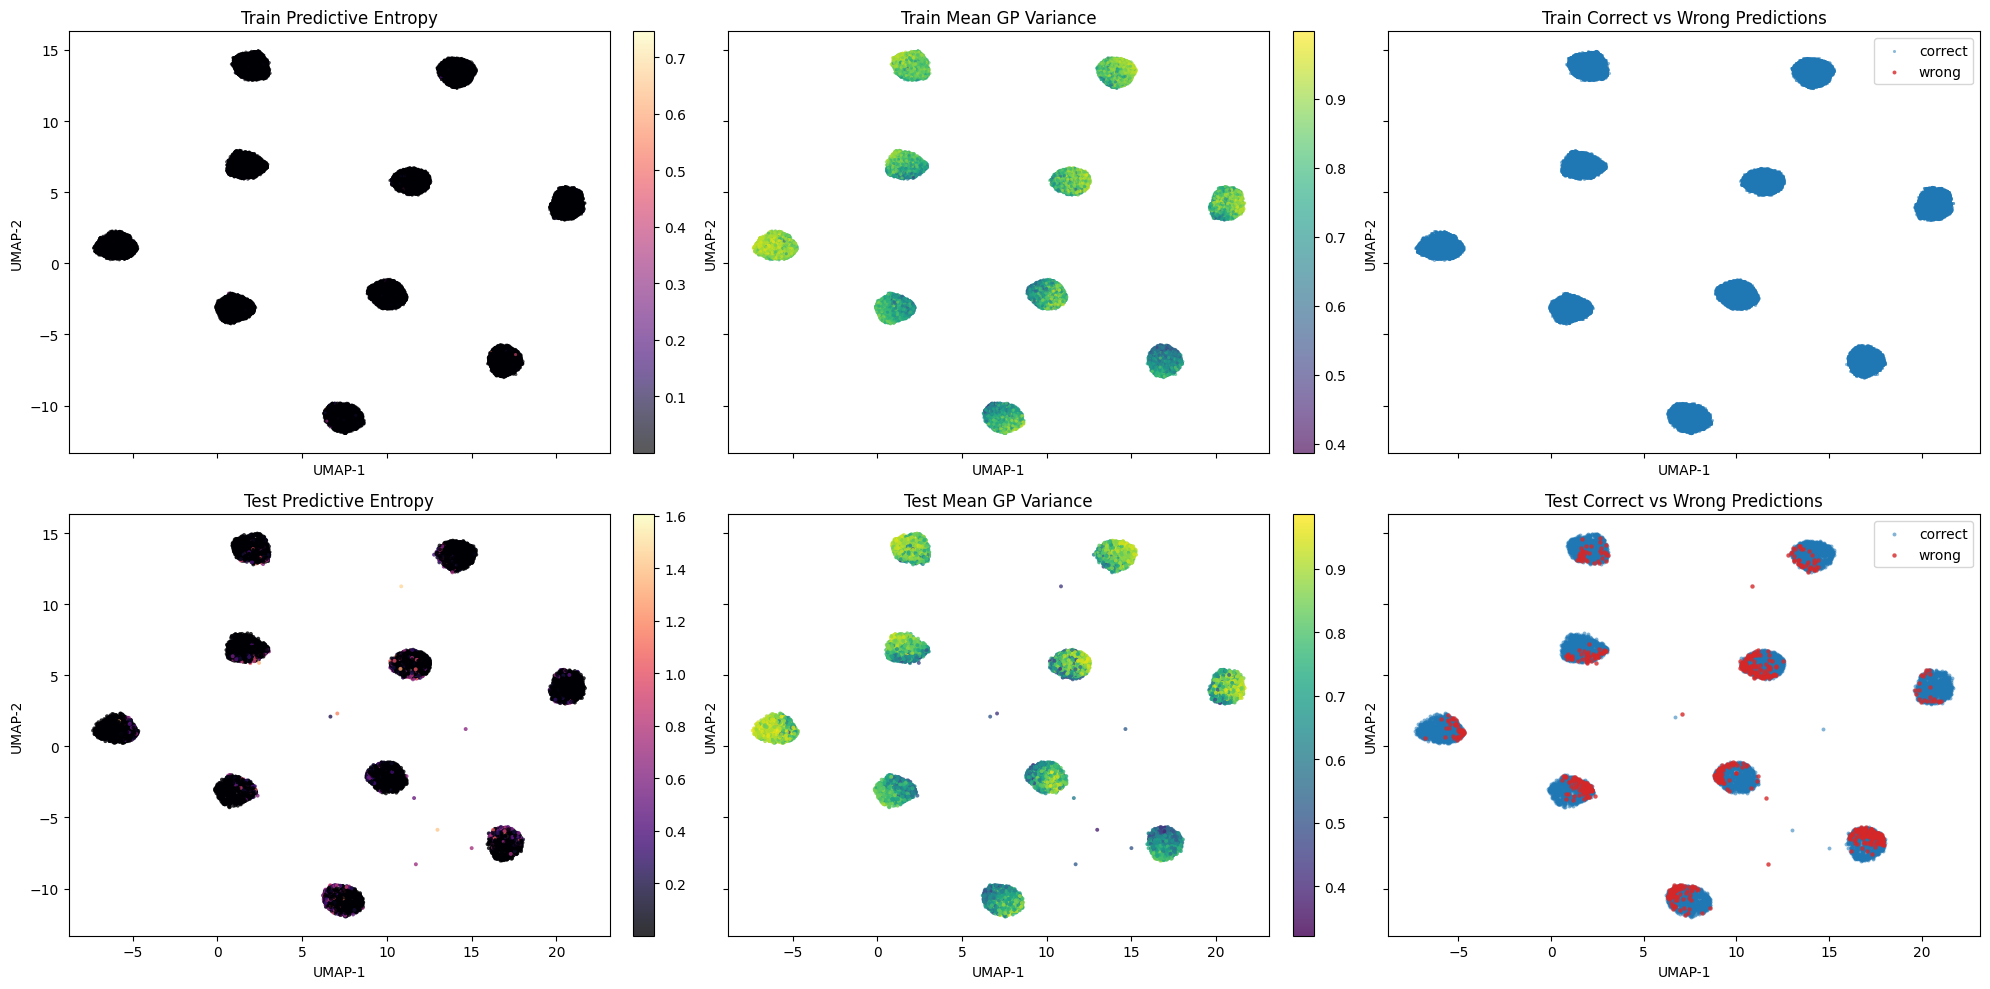

In [6]:
if (
    train_entropy is not None
    and train_gp_variance is not None
    and train_correct_mask is not None
    and test_entropy is not None
    and test_gp_variance is not None
    and test_correct_mask is not None
):
    fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

    train_entropy_plot = axes[0, 0].scatter(
        train_embedding_2d[:, 0],
        train_embedding_2d[:, 1],
        c=train_entropy,
        cmap="magma",
        s=5,
        alpha=0.65,
        linewidths=0,
    )
    axes[0, 0].set_title("Train Predictive Entropy")
    axes[0, 0].set_xlabel("UMAP-1")
    axes[0, 0].set_ylabel("UMAP-2")
    plt.colorbar(train_entropy_plot, ax=axes[0, 0], fraction=0.046, pad=0.04)

    train_variance_plot = axes[0, 1].scatter(
        train_embedding_2d[:, 0],
        train_embedding_2d[:, 1],
        c=train_gp_variance,
        cmap="viridis",
        s=5,
        alpha=0.65,
        linewidths=0,
    )
    axes[0, 1].set_title("Train Mean GP Variance")
    axes[0, 1].set_xlabel("UMAP-1")
    axes[0, 1].set_ylabel("UMAP-2")
    plt.colorbar(train_variance_plot, ax=axes[0, 1], fraction=0.046, pad=0.04)

    axes[0, 2].scatter(
        train_embedding_2d[train_correct_mask, 0],
        train_embedding_2d[train_correct_mask, 1],
        c="#1f77b4",
        s=5,
        alpha=0.5,
        linewidths=0,
        label="correct",
    )
    axes[0, 2].scatter(
        train_embedding_2d[~train_correct_mask, 0],
        train_embedding_2d[~train_correct_mask, 1],
        c="#d62728",
        s=8,
        alpha=0.8,
        linewidths=0,
        label="wrong",
    )
    axes[0, 2].set_title("Train Correct vs Wrong Predictions")
    axes[0, 2].set_xlabel("UMAP-1")
    axes[0, 2].set_ylabel("UMAP-2")
    axes[0, 2].legend(loc="best")

    test_entropy_plot = axes[1, 0].scatter(
        test_embedding_2d[:, 0],
        test_embedding_2d[:, 1],
        c=test_entropy,
        cmap="magma",
        s=8,
        alpha=0.8,
        linewidths=0,
    )
    axes[1, 0].set_title("Test Predictive Entropy")
    axes[1, 0].set_xlabel("UMAP-1")
    axes[1, 0].set_ylabel("UMAP-2")
    plt.colorbar(test_entropy_plot, ax=axes[1, 0], fraction=0.046, pad=0.04)

    test_variance_plot = axes[1, 1].scatter(
        test_embedding_2d[:, 0],
        test_embedding_2d[:, 1],
        c=test_gp_variance,
        cmap="viridis",
        s=8,
        alpha=0.8,
        linewidths=0,
    )
    axes[1, 1].set_title("Test Mean GP Variance")
    axes[1, 1].set_xlabel("UMAP-1")
    axes[1, 1].set_ylabel("UMAP-2")
    plt.colorbar(test_variance_plot, ax=axes[1, 1], fraction=0.046, pad=0.04)

    axes[1, 2].scatter(
        test_embedding_2d[test_correct_mask, 0],
        test_embedding_2d[test_correct_mask, 1],
        c="#1f77b4",
        s=8,
        alpha=0.55,
        linewidths=0,
        label="correct",
    )
    axes[1, 2].scatter(
        test_embedding_2d[~test_correct_mask, 0],
        test_embedding_2d[~test_correct_mask, 1],
        c="#d62728",
        s=10,
        alpha=0.8,
        linewidths=0,
        label="wrong",
    )
    axes[1, 2].set_title("Test Correct vs Wrong Predictions")
    axes[1, 2].set_xlabel("UMAP-1")
    axes[1, 2].set_ylabel("UMAP-2")
    axes[1, 2].legend(loc="best")

    plt.tight_layout()
    plt.show()


In [7]:
# umap_output_path = REPO_ROOT / "notebooks" / "gmm" / f"sngp_umap_{checkpoint_id}.npz"
# np.savez_compressed(
#     umap_output_path,
#     train_umap=train_embedding_2d,
#     train_labels=train_labels,
#     train_preds=train_preds,
#     train_correct_mask=train_correct_mask,
#     train_entropy=train_entropy,
#     train_gp_variance=train_gp_variance,
#     test_umap=test_embedding_2d,
#     test_labels=test_labels,
#     test_preds=test_preds,
#     test_correct_mask=test_correct_mask,
#     test_entropy=test_entropy,
#     test_gp_variance=test_gp_variance,
#     classes=classes,
#     checkpoint_id=checkpoint_id,
#     embedding_path=str(EMBEDDING_PATH),
# )
# print("saved:", umap_output_path)
